#### Source Kaggle: https://www.kaggle.com/datasets/hubertsidorowicz/steam-games-dataset-daily-updates

In [ ]:
import pandas as pd
import numpy as np
from typing import List, Dict, AnyStr
import ast

In [ ]:
df = pd.read_csv("steam_games.csv", low_memory=False)
columns: List[AnyStr] = ['app_id', 'name', 'release_date', 'price', 'price_status', 'estimated_owners', 'developers', 'publishers', 'genres', 'categories',
'tags', 'positive', 'negative', 'recommendations', 'average_playtime_forever', 'median_playtime_forever', 'average_playtime_2weeks', 'median_playtime_2weeks', 'short_description', 'about_the_game',
'detailed_description', 'supported_languages', 'windows','mac', 'linux', 'steam_store_available', 'steam_spy_available']

pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

df = df.loc[:, columns]
df.shape

(139953, 27)

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 139953 entries, 0 to 139952
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_id                    139953 non-null  int64  
 1   name                      139936 non-null  str    
 2   release_date              139870 non-null  str    
 3   price                     138774 non-null  float64
 4   price_status              139953 non-null  str    
 5   estimated_owners          139953 non-null  str    
 6   developers                139953 non-null  str    
 7   publishers                139953 non-null  str    
 8   genres                    139953 non-null  str    
 9   categories                139953 non-null  str    
 10  tags                      139953 non-null  str    
 11  positive                  139953 non-null  int64  
 12  negative                  139953 non-null  int64  
 13  recommendations           107646 non-null  float64
 14 

## Filters

In [65]:
# #Using custom filters for better insights:
# name_filt = df.name.str.contains("race", na=False, case=False)

# tags = "|".join(["Simulations", "Racing", "Race", "Action"])
# tag_filt = df.tags.str.contains(tags, case=False, na=False, regex=True)

# conditions = name_filt | tag_filt
# df = df.loc[conditions].reset_index(drop=True)
# df

### Cleaning Release Date Column:

In [66]:
# NA value fill with research value for the game: For this case, we have only one value NA
df.loc[df.release_date.isna(), 'release_date'] = '2011-03-15'

In [67]:
#Converting into datetime:
df['release_date'] = pd.to_datetime(df['release_date'], format="%Y-%m-%d")

# Assgning year for better grouping in future:
df['year'] = df.release_date.dt.year

# Assigning Catetogies:
df['price_status'] = df['price_status'].astype("category")
df['estimated_owners'] = df['estimated_owners'].astype("category")

In [68]:
df.head(2)

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,tags,positive,negative,recommendations,average_playtime_forever,median_playtime_forever,average_playtime_2weeks,median_playtime_2weeks,short_description,about_the_game,detailed_description,supported_languages,windows,mac,linux,steam_store_available,steam_spy_available,year
0,886780,Jelly Wrestle,2018-07-28,2.99,paid,0 - 20000,"[""Fury Games Production""]","[""Fury Games Production""]","[""Action"", ""Adventure"", ""Casual"", ""Indie"", ""Si...","[""Single-player"", ""Steam Achievements"", ""Parti...","[""Action"", ""Indie"", ""Casual"", ""Simulation"", ""S...",2,0,0.0,0,0,0,0,Be a part of the battle in the fairy world of ...,Open the world filled with amazing jelly heroe...,Open the world filled with amazing jelly heroe...,"[""English"", ""Russian""]",True,False,False,True,True,2018
1,886820,Nelke & the Legendary Alchemists ~Ateliers of ...,2019-03-25,59.99,paid,20000 - 50000,"[""KOEI TECMO GAMES CO., LTD.""]","[""KOEI TECMO GAMES CO., LTD.""]","[""RPG""]","[""Single-player"", ""Steam Achievements"", ""Parti...","[""RPG"", ""City Builder"", ""Anime"", ""Female Prota...",208,61,227.0,450,227,0,0,Atelier 20th Anniversary Title An Atelier town...,Atelier 20th Anniversary Title An Atelier town...,Crossover characters are from these games: Ate...,"[""English"", ""Traditional Chinese"", ""Japanese""]",True,False,False,True,True,2019


### Cleaning of Estimated_Owners:

In [69]:
# Override commas and .. to ideal values:
df.estimated_owners = df.estimated_owners.str.replace(",", "")
df.estimated_owners = df.estimated_owners.str.replace("..", "-")

# Dropping rows for unwanted categories:
df.drop(df[df.estimated_owners == "0 - 0"].index, inplace=True)

# Value Counts Categories:
df.estimated_owners.value_counts()

# Reset index
df.reset_index(drop=True, inplace=True)

#### Cleaning Developers column:

In [70]:
# Replcing NaN and Empty values to Unknown:
df.loc[df.developers == '[]', 'developers'] = 'Unknown'


# Removing, replacing unwanted characters like []"",
df.loc[:, 'developers'] = df.developers.str.strip("[]").str.replace({'"': '', ',': ' and'})

#### Cleaning Publisher column:

In [71]:
# Replcing Empty values to Unknown:
df.loc[df.publishers == '[]', 'publishers'] = 'Unknown'


# Removing, replacing unwanted characters like []"",
df.loc[:, 'publishers'] = df.publishers.str.strip("[]").str.replace({'"': '', ',': ' and'})

df.reset_index(drop=True, inplace=True)

#### Cleaning and Processing Genres column:

In [72]:
# Genres are mixed column values where List and Dict can be found inside string values I can observe, Better to create separate custom logic function here.

import json 

# Assigning unique genre value in different dataframe:
gen_df = df.loc[df.genres.str.contains('{'), 'genres'].sort_values().apply(json.loads).explode().reset_index(drop=True)
gen_df = gen_df.drop_duplicates().reset_index(drop=True)
gen_df.shape


(28,)

In [73]:
genres_dict = {}
for genre in gen_df:
    genres_dict[genre['id']] = genre['description']

# All genre found across all dataframe
genres_dict

# Note: We can map further this using NLP or Extrnal API to genres column after this if required.

{'1': 'Action',
 '18': 'Sports',
 '2': 'Strategy',
 '70': 'Early Access',
 '37': 'Free To Play',
 '23': 'Indie',
 '4': 'Casual',
 '28': 'Simulation',
 '54': 'Education',
 '60': 'Game Development',
 '29': 'Massively Multiplayer',
 '3': 'RPG',
 '9': 'Racing',
 '25': 'Adventure',
 '57': 'Utilities',
 '80': 'Movie',
 '51': 'Animation & Modeling',
 '52': 'Audio Production',
 '53': 'Design & Illustration',
 '59': 'Web Publishing',
 '56': 'Software Training',
 '55': 'Photo Editing',
 '50': 'Accounting',
 '58': 'Video Production',
 '71': 'Sexual Content',
 '72': 'Nudity',
 '73': 'Violent',
 '74': 'Gore'}

#### Cleaning and Categories column:

In [74]:
# Same step from genres column we apply to categories column. The nature of values are similar hence we can follow same step from above.

import json 

cat_df = df.loc[df.categories.str.contains('{'), 'categories'].sort_values().apply(json.loads).explode().reset_index(drop=True)
cat_df = cat_df.drop_duplicates().reset_index(drop=True)
cat_df.shape

(69,)

In [75]:
cat_dict = {}
for cat in cat_df:
    cat_dict[cat['id']] = cat['description']

cat_dict

# Note: We can map further this using NLP or Extrnal API to genres column after this if required.

{1: 'Multi-player',
 18: 'Partial Controller Support',
 15: 'Stats',
 25: 'Steam Leaderboards',
 62: 'Family Sharing',
 20: 'MMO',
 22: 'Steam Achievements',
 29: 'Steam Trading Cards',
 13: 'Captions available',
 35: 'In-App Purchases',
 23: 'Steam Cloud',
 17: 'Includes level editor',
 27: 'Cross-Platform Multiplayer',
 28: 'Full controller support',
 66: 'Color Alternatives',
 68: 'Custom Volume Controls',
 75: 'Keyboard Only Option',
 76: 'Mouse Only Option',
 74: 'Playable without Timed Input',
 77: 'Touch Only Option',
 67: 'Camera Comfort',
 79: 'Save Anytime',
 8: 'Valve Anti-Cheat enabled',
 55: 'DualShock Controller Support',
 36: 'Online PvP',
 37: 'Shared/Split Screen PvP',
 9: 'Co-op',
 38: 'Online Co-op',
 39: 'Shared/Split Screen Co-op',
 49: 'PvP',
 80: '#category_playable_at_your_own_pace',
 30: 'Steam Workshop',
 64: 'Adjustable Text Size',
 56: 'DualShock Controller Support',
 57: 'DualSense Controller Support',
 58: 'DualSense Controller Support',
 69: 'Stereo Sound

#### Cleaning and Tags column:

In [76]:
# Tags are mixed column values same as Genres and Categories columns, We follow same step again to indetify unique values.

import json 

tag_df = df.loc[df.tags.str.contains('{'), 'tags'].sort_values().apply(json.loads).explode().reset_index(drop=True)
tag_df = tag_df.drop_duplicates().reset_index(drop=True)
tag_df.shape
tag_df = tag_df.tolist()
tag_df

# Note: We can map further this using NLP or Extrnal API to genres column after this if required.

['1980s',
 'Retro',
 'Great Soundtrack',
 'Indie',
 'Automobile Sim',
 'Rhythm',
 'Action',
 'Arcade',
 'Music',
 'Cyberpunk',
 'Racing',
 'Difficult',
 'Driving',
 'Singleplayer',
 'Atmospheric',
 'Runner',
 "1990's",
 'Simulation',
 'Point & Click',
 'Surreal',
 'Alternate History',
 'Detective',
 'Story Rich',
 'Funny',
 'Puzzle',
 'Psychedelic',
 'Interactive Fiction',
 'Mystery',
 'Adventure',
 'Psychological',
 'Fantasy',
 'Education',
 'Programming',
 'Platformer',
 'Controller',
 'Old School',
 'Strategy',
 'Family Friendly',
 'Logic',
 '2D Platformer',
 '2D',
 'Cute',
 'Female Protagonist',
 'Investigation',
 'Hand-drawn',
 'Cartoony',
 'Conspiracy',
 'Historical',
 'Immersive',
 'Exploration',
 'Drama',
 'Cinematic',
 'Casual',
 'Precision Platformer',
 'Pixel Graphics',
 'Fast-Paced',
 'Colorful',
 '2.5D',
 'Puzzle-Platformer',
 'Dark',
 'Horror',
 'Multiple Endings',
 'Ambient',
 'Minimalist',
 'Action-Adventure',
 'Narrative',
 '3D Platformer',
 'Side Scroller',
 'Linear',

### Dropping Null Values for required columns:        

In [91]:
df.dropna(subset=['name', 'price', 'supported_languages', 'windows', 'mac', 'linux'], inplace=True)
df.reset_index(inplace=True, drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117583 entries, 0 to 117582
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   index                     117583 non-null  int64         
 1   app_id                    117583 non-null  int64         
 2   name                      117583 non-null  str           
 3   release_date              117583 non-null  datetime64[us]
 4   price                     117583 non-null  float64       
 5   price_status              117583 non-null  category      
 6   estimated_owners          117583 non-null  str           
 7   developers                117583 non-null  str           
 8   publishers                117583 non-null  str           
 9   genres                    117583 non-null  str           
 10  categories                117583 non-null  str           
 11  tags                      117583 non-null  str           
 12  positive     

### Cleaning and Processing Supported Languages:

In [90]:
# Custom logic to select languages:

def custom_language(x, languages):
    found = 0
    for lan in languages:
        if x.count(lan) >= 1:
            found += 1
    return len(languages) == found

# We can chage language here as required, Custom logic tries to find exactly supported languages which pass given here.
languages = ['German']
df[df.supported_languages.apply(custom_language, languages=languages)].shape


(31523, 30)

### Grouping columns based on preferences:

##### Group 1 (Popularity):

In [78]:
labels = ["Extreme Low", "Low", "Below Average", "Average", "Above Avarage", "Decent", "High", "Extreme High", "Legend", "Elite"]
bins = [-1, 100, 500, 1000, 5000, 10000, 20000, 50000, 100000, 10_00_000, 1_00_00_000]

# New column popularity established:
df.loc[:, 'popularity'] = pd.cut(df.positive, bins=bins, labels=labels).astype('category')

In [79]:
for name, group in df.groupby('popularity'):
    print(name, "->", group.shape)

# Note the number of each group results we have, Structured data are awesome to visualize.

Extreme Low -> (97851, 30)
Low -> (10618, 30)
Below Average -> (2832, 30)
Average -> (3901, 30)
Above Avarage -> (899, 30)
Decent -> (628, 30)
High -> (454, 30)
Extreme High -> (195, 30)
Legend -> (196, 30)
Elite -> (9, 30)


##### Group 2 (Year):

In [80]:
for name, group in df.groupby('year'):
    print(name, "->", group.shape)

# Note: Recent year has more Steam games published as per the grouping lies in.

1997 -> (2, 30)
1998 -> (1, 30)
1999 -> (2, 30)
2000 -> (2, 30)
2001 -> (4, 30)
2002 -> (1, 30)
2003 -> (3, 30)
2004 -> (5, 30)
2005 -> (6, 30)
2006 -> (64, 30)
2007 -> (82, 30)
2008 -> (148, 30)
2009 -> (303, 30)
2010 -> (235, 30)
2011 -> (278, 30)
2012 -> (307, 30)
2013 -> (447, 30)
2014 -> (1469, 30)
2015 -> (2424, 30)
2016 -> (3985, 30)
2017 -> (5711, 30)
2018 -> (7267, 30)
2019 -> (7198, 30)
2020 -> (8681, 30)
2021 -> (9559, 30)
2022 -> (10030, 30)
2023 -> (11584, 30)
2024 -> (15384, 30)
2025 -> (14556, 30)
2026 -> (17845, 30)


##### Group 3 (Popularity and Year Combination):

In [81]:
# We are checking popular Steam across year now:

popular_all_time = df.groupby(['popularity', 'year'])
# All groups are visible:
for name, group in popular_all_time:
    print(name, "->", group.shape)

('Extreme Low', 2003) -> (1, 30)
('Extreme Low', 2005) -> (2, 30)
('Extreme Low', 2006) -> (13, 30)
('Extreme Low', 2007) -> (9, 30)
('Extreme Low', 2008) -> (34, 30)
('Extreme Low', 2009) -> (84, 30)
('Extreme Low', 2010) -> (75, 30)
('Extreme Low', 2011) -> (75, 30)
('Extreme Low', 2012) -> (49, 30)
('Extreme Low', 2013) -> (48, 30)
('Extreme Low', 2014) -> (499, 30)
('Extreme Low', 2015) -> (1174, 30)
('Extreme Low', 2016) -> (2400, 30)
('Extreme Low', 2017) -> (4161, 30)
('Extreme Low', 2018) -> (5704, 30)
('Extreme Low', 2019) -> (5663, 30)
('Extreme Low', 2020) -> (6921, 30)
('Extreme Low', 2021) -> (7890, 30)
('Extreme Low', 2022) -> (8476, 30)
('Extreme Low', 2023) -> (9876, 30)
('Extreme Low', 2024) -> (13385, 30)
('Extreme Low', 2025) -> (13585, 30)
('Extreme Low', 2026) -> (17727, 30)
('Low', 2001) -> (1, 30)
('Low', 2006) -> (20, 30)
('Low', 2007) -> (16, 30)
('Low', 2008) -> (50, 30)
('Low', 2009) -> (96, 30)
('Low', 2010) -> (66, 30)
('Low', 2011) -> (72, 30)
('Low', 2012

In [82]:
# Let's look after for Elite and Legend games only across all years
grp_s1 = popular_all_time.size()
grp_s1.loc[slice("Legend", "Elite"), slice(2015, 2026), :]

popularity  year
Legend      2015    15
            2016    17
            2017    19
            2018    19
            2019    17
            2020    26
            2021    12
            2022    10
            2023     8
            2024    12
            2025     4
            2026     1
Elite       2015     1
            2017     1
            2018     1
            2024     1
dtype: int64

### Time Series Analysis:

<Figure size 1600x1000 with 0 Axes>

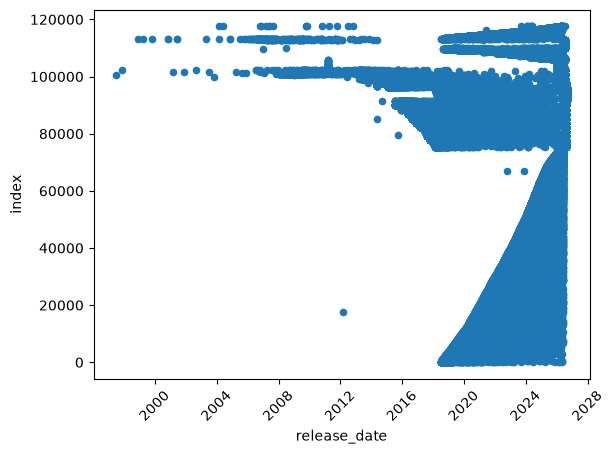

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10))
df.plot(kind='scatter', x='release_date', y='index', rot=45)
plt.show()

In [129]:
df

,index,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,tags,positive,negative,recommendations,average_playtime_forever,median_playtime_forever,average_playtime_2weeks,median_playtime_2weeks,short_description,about_the_game,detailed_description,supported_languages,windows,mac,linux,steam_store_available,steam_spy_available,year,popularity
0,0,886780,Jelly Wrestle,2018-07-28,2.99,paid,0 - 20000,Fury Games Production,Fury Games Production,"[""Action"", ""Adventure"", ""Casual"", ""Indie"", ""Si...","[""Single-player"", ""Steam Achievements"", ""Parti...","[""Action"", ""Indie"", ""Casual"", ""Simulation"", ""S...",2,0,0.0,0,0,0,0,Be a part of the battle in the fairy world of ...,Open the world filled with amazing jelly heroe...,Open the world filled with amazing jelly heroe...,"[""English"", ""Russian""]",True,False,False,True,True,2018,Extreme Low
1,1,886820,Nelke & the Legendary Alchemists ~Ateliers of ...,2019-03-25,59.99,paid,20000 - 50000,KOEI TECMO GAMES CO. and LTD.,KOEI TECMO GAMES CO. and LTD.,"[""RPG""]","[""Single-player"", ""Steam Achievements"", ""Parti...","[""RPG"", ""City Builder"", ""Anime"", ""Female Prota...",208,61,227.0,450,227,0,0,Atelier 20th Anniversary Title An Atelier town...,Atelier 20th Anniversary Title An Atelier town...,Crossover characters are from these games: Ate...,"[""English"", ""Traditional Chinese"", ""Japanese""]",True,False,False,True,True,2019,Low
2,2,886830,ParkourMan,2018-07-24,1.99,paid,0 - 20000,Fury Games Production,Fury Games Production,"[""Action"", ""Adventure"", ""Casual"", ""Indie"", ""Ra...","[""Single-player"", ""Steam Achievements"", ""Famil...","[""Action"", ""Indie"", ""Casual"", ""Racing"", ""Adven...",5,1,0.0,0,0,0,0,It’s time to shake this city up! ParkourMan is...,Become a real master of the free city run with...,Become a real master of the free city run with...,"[""English"", ""Russian""]",True,False,False,True,True,2018,Extreme Low
3,3,886900,Chef: A Restaurant Tycoon Game,2020-08-20,19.99,paid,50000 - 100000,Innervoid Interactive,Digital Tribe,"[""Simulation""]","[""Single-player"", ""Steam Achievements"", ""Steam...","[""Management"", ""Simulation"", ""Cooking"", ""Chara...",1060,381,1368.0,283,194,0,0,Chef is a Restaurant Management game in which ...,Chef allows you to personally don a kitchen ap...,Chef allows you to personally don a kitchen ap...,"[""English"", ""Italian"", ""Russian"", ""French"", ""P...",True,False,False,True,True,2020,Average
4,4,886950,Roman The Worm,2018-07-17,0.99,paid,0 - 20000,RadM,RadM,"[""Action"", ""Adventure"", ""Casual"", ""Simulation""]","[""Single-player"", ""Steam Achievements"", ""Full ...","[""Casual"", ""Action"", ""Adventure"", ""Simulation""]",29,6,0.0,0,0,0,0,Roman The Worm is a fun and tricky 2D Jump 'n'...,Roman The Worm Roman The Worm is a fun and tri...,Roman The Worm Roman The Worm is a fun and tri...,"[""English"", ""German"", ""Spanish - Spain"", ""Poli...",True,False,False,True,True,2018,Extreme Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117578,117578,4240,RACE - The WTCC Game,2006-11-24,39.99,paid,200000 - 500000,SimBin,SimBin,"[{""id"": ""9"", ""description"": ""Racing""}]","[{""id"": 2, ""description"": ""Single-player""}, {""...","{""Racing"": 54, ""Simulation"": 17}",121,42,NaN,0,0,0,0,The Official WTCC Game | RACE is the first eve...,<strong>The Official WTCC Game |</strong> RACE...,<strong>The Official WTCC Game |</strong> RACE...,"English, French, German, Italian, Spanish - Spain",True,False,False,True,True,2006,Low
117579,117579,4500,S.T.A.L.K.E.R.: Shadow of Chernobyl,2007-03-20,19.99,paid,1000000 - 2000000,GSC Game World,GSC Game World,"[{""id"": ""1"", ""description"": ""Action""}, {""id"": ...","[{""id"": 2, ""description"": ""Single-player""}, {""...","{""Atmospheric"": 1466, ""Post-apocalyptic"": 1356...",44761,2530,37991.0,0,0,0,0,S.T.A.L.K.E.R.: Shadow of Chernobyl

Resolved 20 packages in 2.56s
 Downloaded fonttools
 Downloaded pillow
 Downloaded matplotlib
Prepared 7 packages in 6.99s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 7 packages in 1.30s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.64.0
 + kiwisolver==1.5.1
 + matplotlib==3.11.1
 + pillow==12.3.0
 + pyparsing==3.3.2
